# **Project Name**    -     INSURANCE COST PRICE PREDICTION



##### **Project Type**    - Regression (supervised data)
##### **Contribution**    - Individual

# **Project Summary -**

This project develops a machine learning model to predict individual medical insurance charges based on personal and demographic attributes such as age, sex, BMI, number of children, smoking status, and region. The dataset contains structured insurance records, where the target variable is charges, a continuous numeric value.

The project follows a supervised learning approach, specifically a regression problem, because the goal is to estimate future insurance costs rather than classify records into categories. The workflow includes understanding the business problem, exploring the dataset, preparing the data, selecting relevant features, training a predictive model, and evaluating its performance.

This project is useful because medical insurance cost estimation can support pricing decisions, risk assessment, customer planning, and business strategy. By identifying the major factors that influence insurance charges, the model helps transform raw customer data into actionable insights.

# **GitHub Link -**
https://github.com/priyankamanik35-lgtm/Insurance_Cost_Prediction

## **Problem Statement**


#### **Define Your Business Objective?**

Define Your Business Objective
The main business objective of this project is to build a predictive system that can estimate medical insurance charges accurately and consistently using customer-related attributes.

Insurance providers and healthcare-related businesses need a reliable way to forecast costs in order to improve premium planning, financial risk management, and customer transparency. Manual estimation can be slow, inconsistent, and may fail to capture patterns hidden in historical data. A machine learning model can help solve this by learning the relationship between input variables and insurance charges from past records.

In this project, the problem can be defined as:

How can we use customer demographic and health-related information to predict medical insurance charges as accurately as possible?

The project also aims to answer a few supporting business questions:

Which features have the strongest impact on insurance charges?
How much does smoking status affect predicted cost?
Can the model help businesses make data-driven pricing decisions?
Can customers get a better estimate of likely medical expenses based on their profile?
So, the final business goal is not just prediction, but also better decision-making through data.

# ***Let's Begin !***

## ***1. Know Your Data***

In [2]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
import pickle

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [3]:
# Reading csv file
df = pd.read_csv("Insurance_Datasets.csv")

In [4]:
# dataset view
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# dataset shape
df.shape  

(1338, 7)

## ***2. Understanding Your Variables***

In [6]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
# Statistical calculation of all numerical columns
df.describe()   

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
# Statistical calculation of cate
df.describe(include="O")

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [9]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [10]:
print(df["sex"].value_counts())
print("\n",df["smoker"].value_counts())
print("\n",df["region"].value_counts())

sex
male      676
female    662
Name: count, dtype: int64

 smoker
no     1064
yes     274
Name: count, dtype: int64

 region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


#### What did you know about your dataset?
This is the classic **medical insurance charges** dataset — 1,338 rows, 7 columns, no missing values.

**Column overview:**
- `age` —  age of primary beneficiary 18 to 64 (mean ~39)
- `sex` —  insurance contractor gender (676 male, 662 female — roughly balanced)
- `bmi` — Body mass index, providing an understanding of body, weights that are relatively high or low relative to height,
               objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9 
- `children` — number of dependents covered by health insurance / Number of dependents
- `smoker` — yes/no (1,064 non-smokers, 274 smokers)
- `region` — The beneficiary's residential area in the US - southwest, northwest,northeast, southeast (most frequent, 364)
- `charges` — the target variable: individual insutance cost billed by health insurance

This is a well-known synthetic/teaching dataset (often used in ML tutorials) for predicting insurance charges based on demographic and lifestyle factors — `smoker` status and `bmi` are typically the strongest predictors of high charges.


##### Now we observed data as it has 3 categorical features and 3 numerical features and 1 label . It is a supervised data as we have some previous data with label column. Also we got to know that we don't have any missing value so we can further proceed to know the features better.

## ***3. DATA WRANGLING***

In [11]:
# Checking for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

##### Our dataset has no NULL value .There is no missing value.So we have a cleaned data for visualization.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

## *Chart - 1 : COUNTPLOT*
### count of sex,smokers and different regions


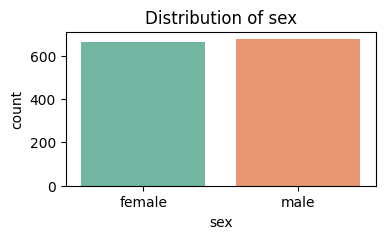

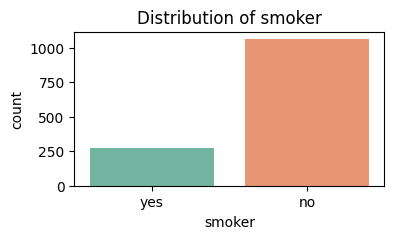

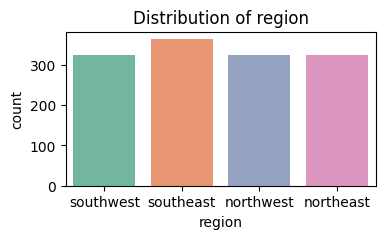

In [12]:
# countplot for categorical feat
cat_cols = ["sex", "smoker", "region"]
for col in cat_cols:
    plt.figure(figsize=(4,2))
    sns.countplot(x=col, palette="Set2", data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

#### 1. Why did you pick the specific chart?

A countplot is used to compare the number of observations in each category of a categorical variable. It helps us quickly understand the distribution of sex, smoker status, and region in the dataset.

#### 2. What are the insight(s) found from the chart?

* The dataset contains nearly equal numbers of male and female customers.
* There are more non-smokers than smokers in the dataset.
* The customers are distributed across different regions, which helps us understand the population diversity in the data.
* The countplot shows a relatively balanced sex and regional distribution, while smoker status appears to be uneven and may strongly influence insurance charges.

#### 3. Will the gained insights help creating a positive business impact?

Yes. These insights can create a positive business impact by helping the business understand customer mix and risk patterns. Knowing that smoking status is a major factor in the dataset allows insurers to improve pricing strategies, reduce risk exposure, and design targeted health and wellness initiatives. The analysis also supports better decision-making in customer segmentation, premium planning, and business strategy.


## *Chart - 2 : HISTOGRAM*
### Distribution of age, bmi, children & charges

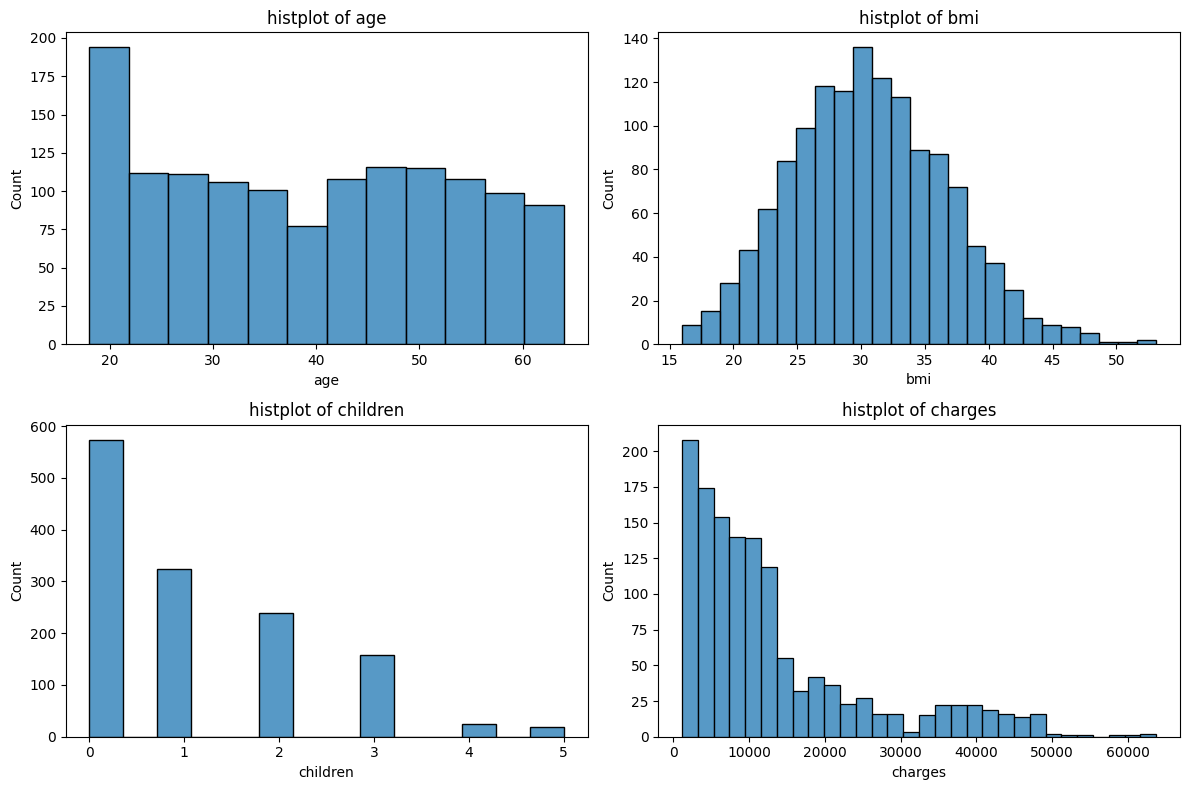

In [13]:
#Distribution of numerical features
num_cols = ["age", "bmi",'children', "charges"]

plot_number = 1
plt.figure(figsize=(12, 8))  # Set the overall figure size
for col in num_cols:
    plt.subplot(2, 2, plot_number)
    sns.histplot(x=col, data=df)
    plt.title(f'histplot of {col}')
    plot_number += 1
plt.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()

### 1. Why did you pick the specific chart?

A histogram is used to visualize the distribution of continuous numerical variables. It helps us understand where most values are concentrated, how spread out the data is, and whether the variable is skewed or has outliers.

### 2. What are the insight(s) found from the chart?

* Age is mostly concentrated in the middle range, with many customers between 20 and 60 years old.
* BMI values are mostly clustered between 25 and 35, which shows that most customers fall in a moderate-to-high BMI range.
* Most customers have 0 to 2 children, while fewer customers have 3 or more children.
* Insurance charges are right-skewed, meaning most customers pay lower charges, but a smaller group pays much higher charges.
* The charges distribution suggests that extreme values exist, which can affect model performance and may require transformation or outlier handling.

### 3. Will the gained insights help creating a positive business impact?

Yes, these insights can create a positive business impact because they help the business understand the customer profile and cost behavior. A skewed insurance charge distribution shows that a small number of customers may drive high costs, which is important for risk assessment and premium planning. By identifying common age and BMI ranges, the company can improve customer segmentation, pricing strategies, and health-focused decision-making. These insights also support more accurate forecasting and stronger business planning.

## *Chart -  3: LINEPLOT*
### Relation of charges with BMI and age 

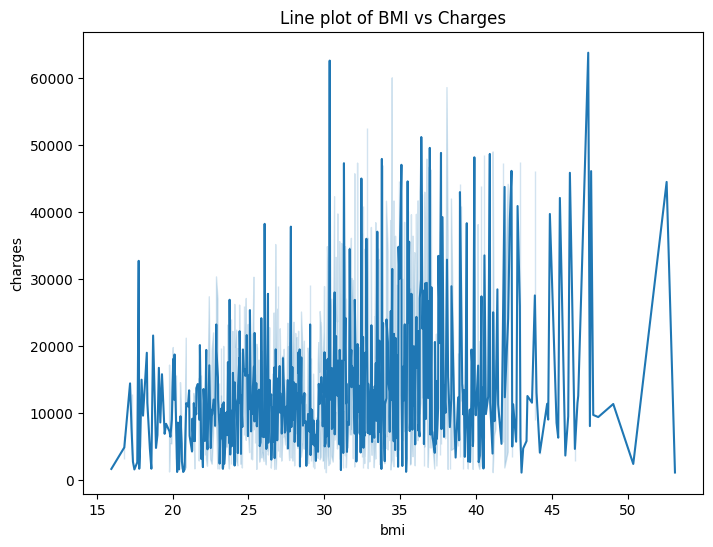

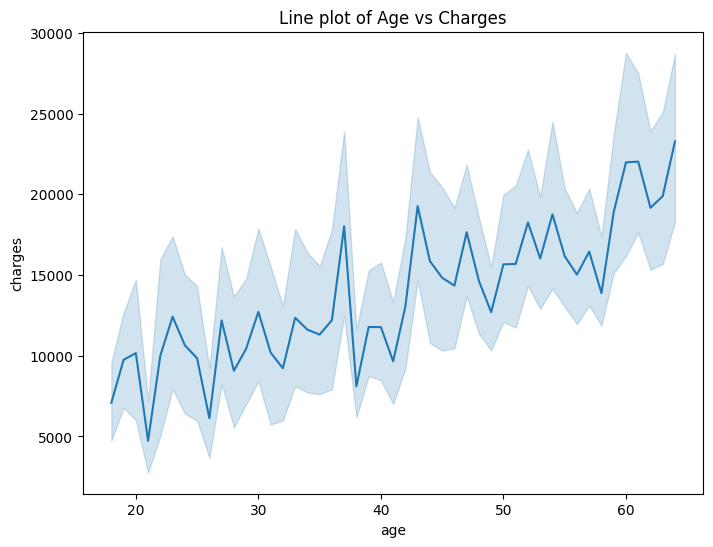

In [14]:
# Lineplot of BMI vs Charges    
plt.figure(figsize=(8,6))
sns.lineplot(data =df,
             x= "bmi",
             y="charges")
plt.title("Line plot of BMI vs Charges")
plt.show()

# Lineplot of Age vs Charges
plt.figure(figsize=(8,6))
sns.lineplot(data =df,
             x= "age",
             y="charges")
plt.title("Line plot of Age vs Charges")
plt.show()

### 1. Why did you pick the specific chart?

A line plot is used to show the trend between two continuous variables and to identify whether there is a pattern or relationship over an ordered axis. In this case, it helps us understand how insurance charges change as BMI & age increases.

### 2. What are the insight(s) found from the chart?

* Insurance charges generally increase as BMI increases.
* The pattern suggests a positive relationship between BMI and medical cost.
* Higher BMI values are associated with higher insurance charges, although there is some variation in the data.
* This indicates that BMI may be an important factor influencing insurance pricing and risk.

* Insurance charges generally increase as age increases.
* Younger customers mostly have lower medical costs.
* Older customers tend to have higher charges, showing a clear upward trend.
* Although there is some variation, the overall pattern suggests that age is an important factor in predicting insurance costs.

### 3. Will the gained insights help creating a positive business impact?

Yes. These insights can create a positive business impact by helping insurers understand that BMI is a meaningful factor in cost prediction and how age strongly influences expected medical costs. This can support better risk assessment, more informed premium decisions, and improved customer segmentation. By identifying cost patterns early, businesses can make smarter pricing and planning decisions while also improving transparency for customers.


## *Chart - 4 : SCATTERPLOT*
### Variation of age, BMI, children according to charges

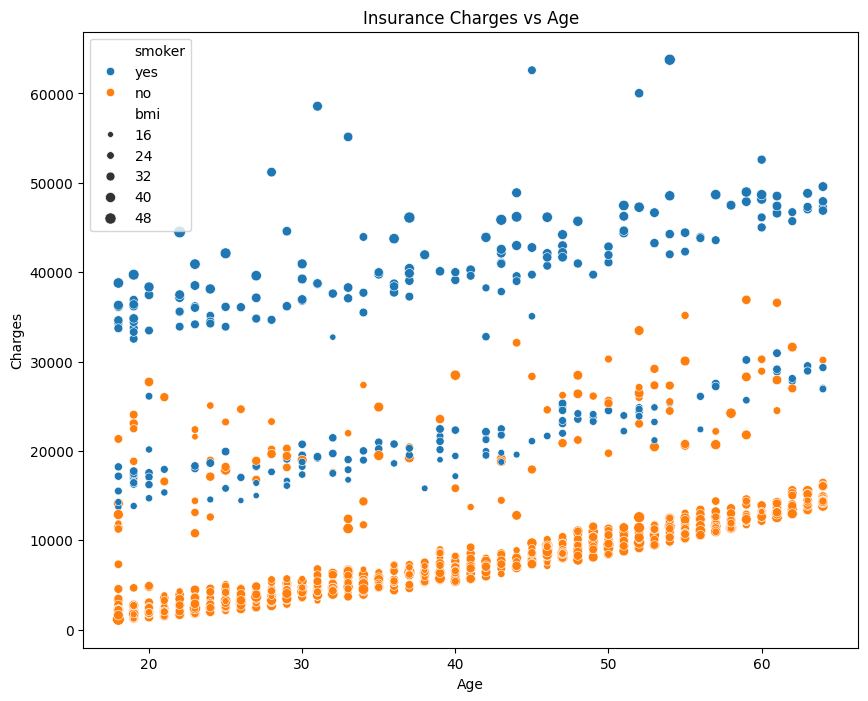

In [15]:
# Scatter Plot: Age vs Charges
plt.figure(figsize=(10,8))
sns.scatterplot(x='age',
                y='charges',
                size = "bmi",
                data=df,
                hue='smoker')
plt.title('Insurance Charges vs Age')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()


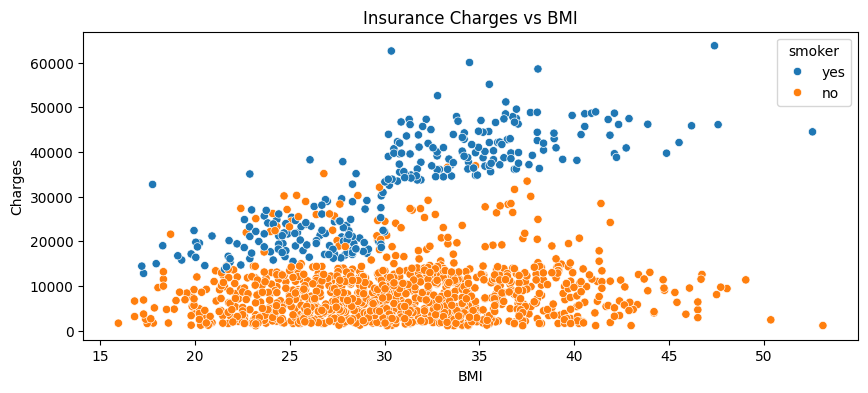

In [16]:
# Scatter Plot: BMI vs Charges
plt.figure(figsize=(10,4))
sns.scatterplot(x='bmi',
                y='charges',
                data=df,
                hue='smoker')
plt.title('Insurance Charges vs BMI')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

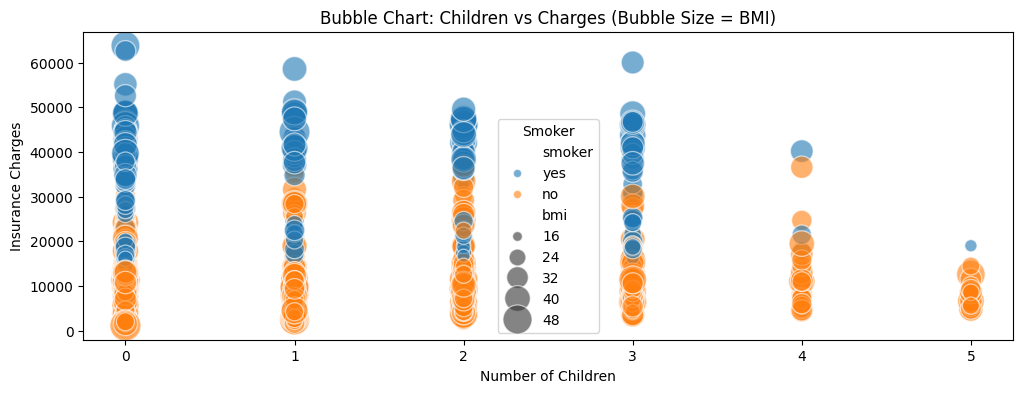

In [17]:
# Bubble Chart: Children vs Charges (Bubble Size = BMI)
plt.figure(figsize=(12,4))
sns.scatterplot(
    x='children', 
    y='charges', 
    size='bmi',
    hue='smoker', 
    data=df, 
    alpha=0.6,      # transparency for better overlap visibility
    sizes=(50, 500) # control bubble size range
)

plt.title('Bubble Chart: Children vs Charges (Bubble Size = BMI)')
plt.xlabel('Number of Children')
plt.ylabel('Insurance Charges')
plt.legend(title='Smoker')
plt.show()


### 1. Why did you pick the specific chart?
A scatter plot is a suitable choice because it helps visualize the relationship between two continuous variables, such as age or BMI and insurance charges, while also showing how smoking status changes the pattern across the dataset. By adding bubble size and color, the chart becomes more informative because it highlights an additional factor and makes it easier to compare cost differences among individuals. 

### 2. What are the insight(s) found from the chart?

BMI vs Charges
* Insurance charges tend to increase as BMI increases.
* Customers with higher BMI values generally have higher medical costs.
* The distribution shows that BMI is positively related to insurance charges, though there is variation across individuals.
* Smokers with higher BMI appear to have the highest charges, showing that BMI and smoking status together strongly influence cost.

Age vs Charges
* Insurance charges tend to rise as age increases.
* Older customers show higher and more spread-out charges compared to younger customers.
* The plot shows a positive relationship between age and cost, though there is some variation among individuals.
* Smokers appear to have much higher charges overall, which suggests that smoking status strongly influences cost along with age.

Children vs Charges
* There is no strong pattern between number of children and insurance charges
* Charges vary widely across all child counts
* Children do not appear to be a major driver of cost

### 3. Will the gained insights help creating a positive business impact?

Yes. These insights can create a positive business impact because they help insurers understand that age, BMI and smoking status are major drivers of healthcare cost while children have not much impact on our cost so we can completely ignore children column.
There is no clear upward or downward trend with number of children.  


## *Chart - 5 : VIOLINPLOT*
### Distribution of Charges by Region and Smoker Status

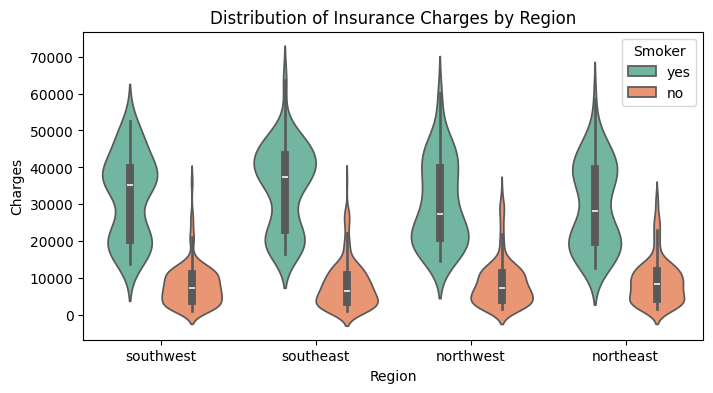

In [18]:
plt.figure(figsize=(8,4))
sns.violinplot(
    x='region', 
    y='charges', 
    data=df, 
    hue='smoker',       # optional: split by smoker status
    palette='Set2'      # nice color palette
)

plt.title('Distribution of Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.show()


### 1. Why did you pick the specific chart?

A violin plot is useful when we want to compare the distribution of a continuous variable across different categories. In this case, it helps us see how insurance charges are spread across the four regions while also separating smokers and non-smokers. This chart is especially valuable because it shows both the density and the spread of the data, making it easier to compare the overall cost patterns between groups.

### 2. What are the insight(s) found from the chart?

* The distribution of insurance charges is broadly similar across all regions, which suggests that region alone is not a major driver of cost.
* Each region shows a wide range of charges, meaning charges vary a lot even within the same area.
* Smokers have much higher insurance charges than non-smokers in every region.
* The violin shapes indicate that premium costs are concentrated at higher values for smokers, while non-smokers mostly stay in the lower-cost range.
* There is no single region with consistently much higher or lower insurance costs than the others.

### 3. Will the gained insights help creating a positive business impact?

Yes. These insights can create a positive business impact because they show that smoking status is a much stronger cost driver than region. This can help insurance companies design better pricing strategies, improve risk assessment, and focus on targeted wellness or prevention programs. By understanding that regional differences are limited while smoking status strongly affects cost, businesses can make more accurate financial decisions and improve customer segmentation.


## *Chart - 6 : BARPLOT*
### Distribution of Average charges by sex and smoker status

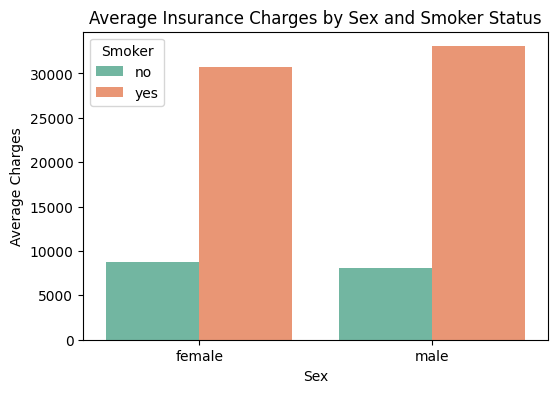

In [19]:
avg_charges = df.groupby(['sex','smoker'])['charges'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(
    x='sex', 
    y='charges', 
    hue='smoker', 
    data=avg_charges, 
    palette='Set2'
)

plt.title('Average Insurance Charges by Sex and Smoker Status')
plt.xlabel('Sex')
plt.ylabel('Average Charges')
plt.legend(title='Smoker')
plt.show()


### 1. Why did you pick the specific chart?

A bar plot is appropriate when we want to compare the average value of a numerical variable across categories. Here, it helps us compare the average insurance charges for males and females separately for smokers and non-smokers. This chart is useful because it summarizes the key business pattern in a simple and interpretable way, making the differences between groups easy to understand.

### 2. What are the insight(s) found from the chart?

* Male smokers have the highest average insurance charges compared to the other groups.
* Female smokers also have high average charges, but their values are lower than male smokers.
* Non-smokers in both sexes have much lower charges, showing that smoking status is the dominant cost driver.
* The difference between males and females is small for non-smokers, suggesting that sex has less impact than smoking status.
* The chart confirms that the cost gap is mainly explained by smoking behavior rather than gender alone.

### 3. Will the gained insights help creating a positive business impact?

Yes. These insights can create a positive business impact because they show that smoking status has a much stronger influence on insurance cost than sex. This helps insurers improve premium modeling, make fairer risk-based pricing decisions, and focus on targeted prevention strategies for smokers. The business can also use these findings to design better policy evaluation and customer segmentation based on actual cost drivers.


## *Chart - 7 : REGPLOT*
### Regression Line: BMI vs Charges

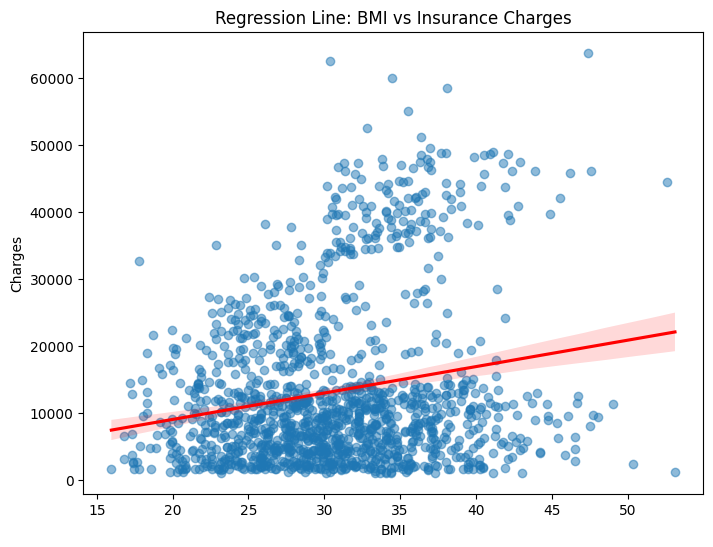

In [20]:
plt.figure(figsize=(8,6))
sns.regplot(
    x='bmi', 
    y='charges', 
    data=df, 
    scatter_kws={'alpha':0.5},   # transparency for scatter points
    line_kws={'color':'red'}     # regression line color
)

plt.title('Regression Line: BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()


### 1. Why did you pick the specific chart?

A regression line chart is useful for understanding the overall trend between a predictor and the target variable. In this case, it shows how insurance charges change as BMI increases and helps us determine whether there is a positive linear relationship. This chart is effective because it combines the raw data points with a fitted trend line, making the pattern easier to interpret and explain.

### 2. What are the insight(s) found from the chart?

* The regression line slopes upward, which indicates a positive relationship between BMI and insurance charges.
* Higher BMI values are generally associated with higher medical costs.
* The data points are spread around the line, so there is variation from person to person, but the overall trend remains increasing.
* This suggests that BMI is an important factor influencing cost, although other variables such as smoking status may also contribute strongly.
* The trend is not perfectly linear for every case, which means the relationship is meaningful but not the only factor affecting charges.

### 3. Will the gained insights help creating a positive business impact?

Yes. These insights can create a positive business impact because they show that BMI is a useful risk indicator for insurance cost. This helps insurers understand pricing trends more accurately, support better premium risk assessment, and improve customer segmentation. By identifying the BMI-cost relationship, the business can make more informed decisions on risk evaluation and health-related pricing strategies.


The regression line slopes upward, showing a positive relationship between BMI and insurance cost.
Higher BMI values are generally associated with higher charges.
The scatter points show individual variation around that trend.
The shaded confidence band indicates the model’s uncertainty, but the overall trend remains increasing.

## *Chart - 8 : BOXPLOT*
### Checking for outliers in our entire data

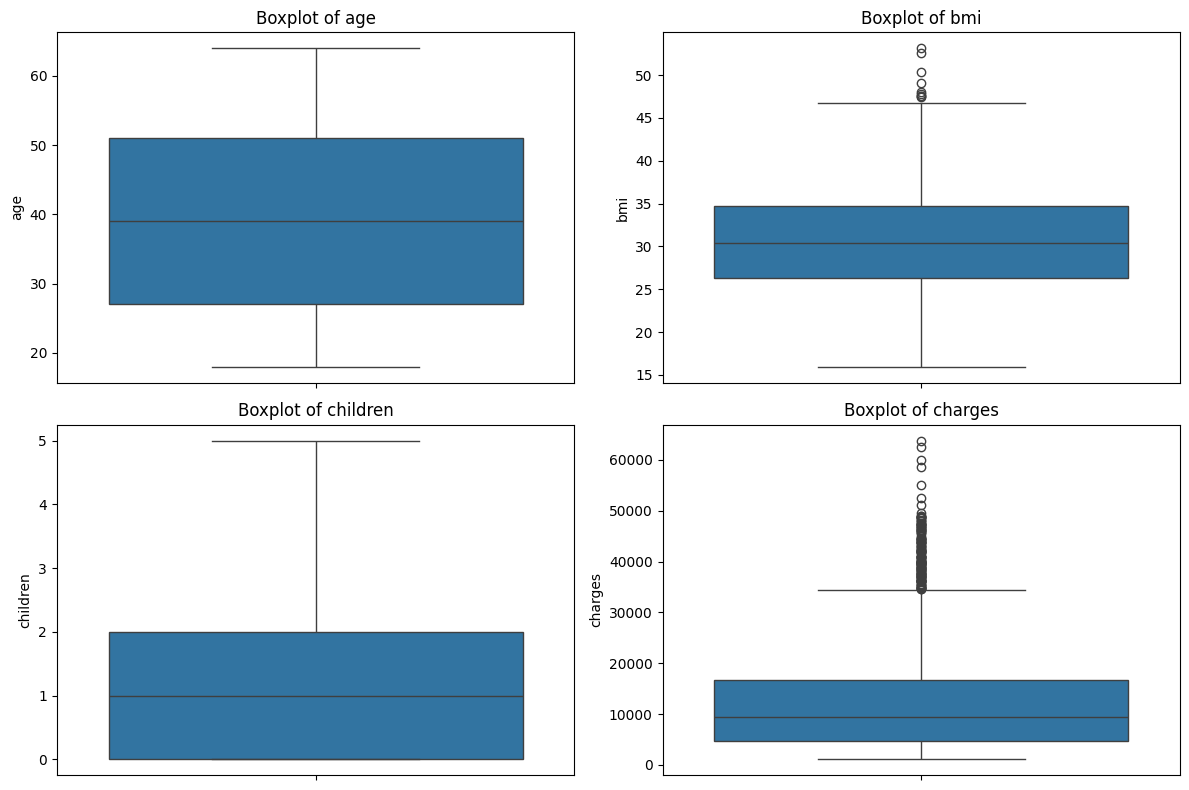

In [21]:
num_col = ['age', 'bmi', 'children', 'charges']

plot_number = 1
plt.figure(figsize=(12, 8))  # Set the overall figure size
for col in num_col:
    plt.subplot(2, 2, plot_number)
    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plot_number += 1
plt.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()

### 1. Why did you pick the specific chart?

A boxplot is useful for understanding the spread, center, and outliers of a numerical variable. In this case, it helps us see how age, BMI, children, and insurance charges are distributed across the dataset. This chart is valuable because it quickly highlights whether a variable has extreme values, which is important when preparing data and evaluating risk patterns.

### 2. What are the insight(s) found from the chart?

* Age is fairly distributed across the dataset, with most values concentrated in the middle range and a few older individuals at the upper end.
* BMI has a moderate spread, with some values at the higher end, suggesting a wider variation in body mass index.
* The number of children is concentrated in the lower range, with most customers having fewer dependents.
* Insurance charges have a much wider spread and several extreme high values, which indicates the presence of outliers.
* The boxplot suggests that charges are right-skewed and may require transformation or outlier handling before building a predictive model.

### 3. Will the gained insights help creating a positive business impact?

Yes. These insights can create a positive business impact because they help the business understand where the extreme cost values are coming from and how data quality can affect prediction accuracy. By identifying outliers in charges, insurers can improve pricing fairness, reduce model distortion, and make better decisions in risk analysis and financial planning.


## *Chart - 9 : HEATMAP*
### Checking correlation with different features

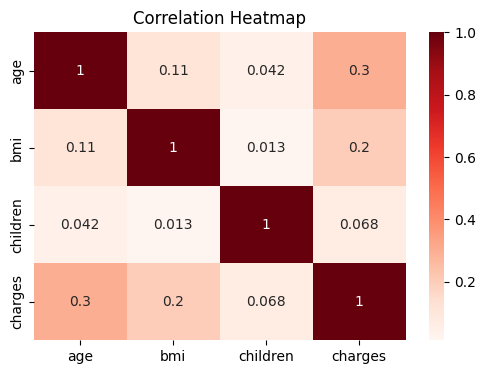

In [22]:
# Correlation heatmap
cols = ['age', 'bmi', 'children', 'charges']
plt.figure(figsize=(6,4))
sns.heatmap(df[cols].corr(), annot=True, cmap="Reds")
plt.title("Correlation Heatmap")
plt.show()


### 1. Why did you pick the specific chart?

A heatmap is used to visualize the correlation between numerical variables in a compact and interpretable way. It helps us quickly identify which features are strongly related to each other and which variables are less important for predicting insurance charges. This chart is useful because it gives a clear overview of the overall data relationships before building a model.

### 2. What are the insight(s) found from the chart?

* Insurance charges show a stronger correlation with age and BMI than with the number of children.
* Children has a weak relationship with charges, suggesting it contributes less to cost variation.
* Age and BMI appear to be more useful predictors of insurance cost than children.
* The heatmap confirms that a few key features are more strongly connected to charges, which helps in feature selection.
* The weak correlation of children indicates that it may not be a major driver of insurance pricing in this dataset.

### 3. Will the gained insights help creating a positive business impact?

Yes. These insights can create a positive business impact because they help businesses focus on the most important cost drivers instead of spending effort on weaker predictors. By identifying age and BMI as stronger relationships, insurers can improve risk assessment, refine premium calculations, and support more accurate cost prediction models. This leads to better pricing decisions and more efficient business planning.


## *Chart - 10 : PAIRPLOT*
### Relationship between features

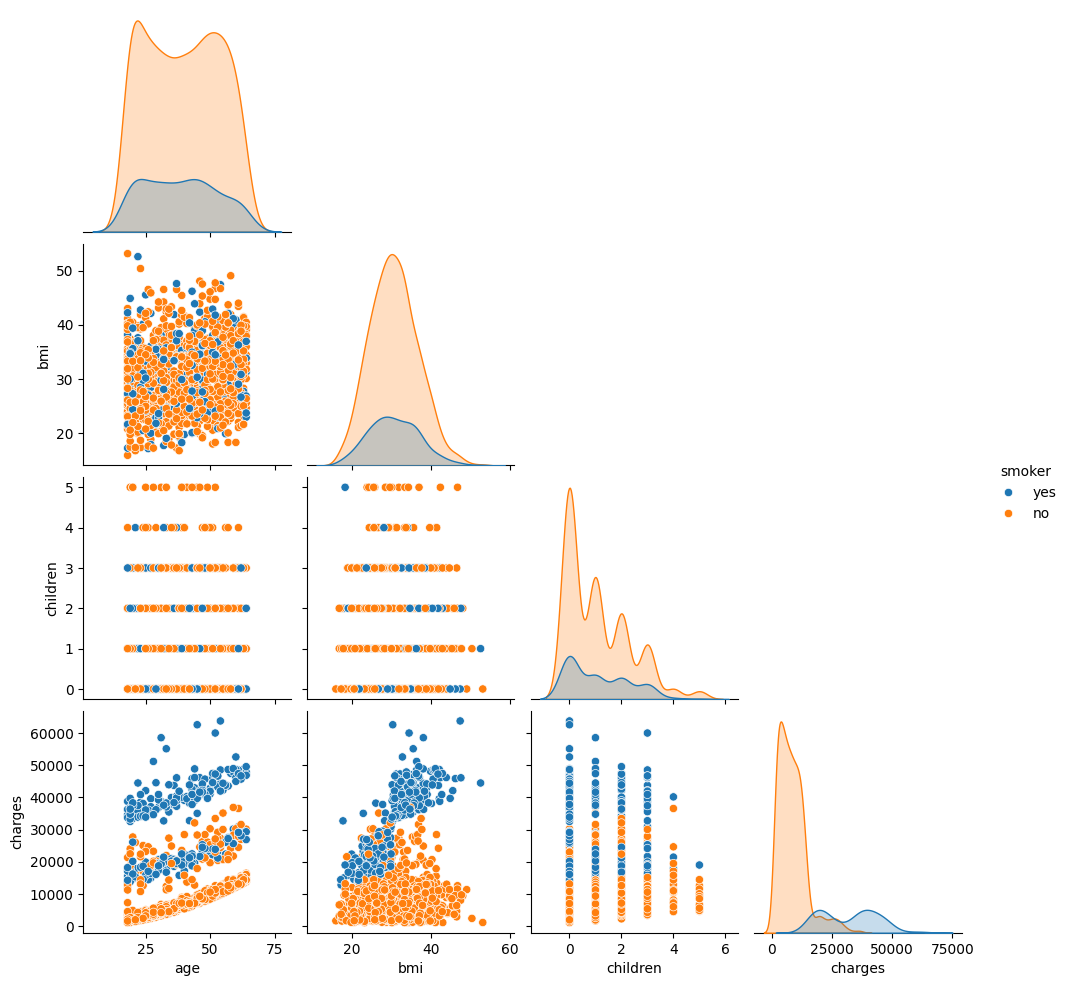

In [23]:
#pairplot
sns.pairplot(data=df,hue='smoker',corner=True,)

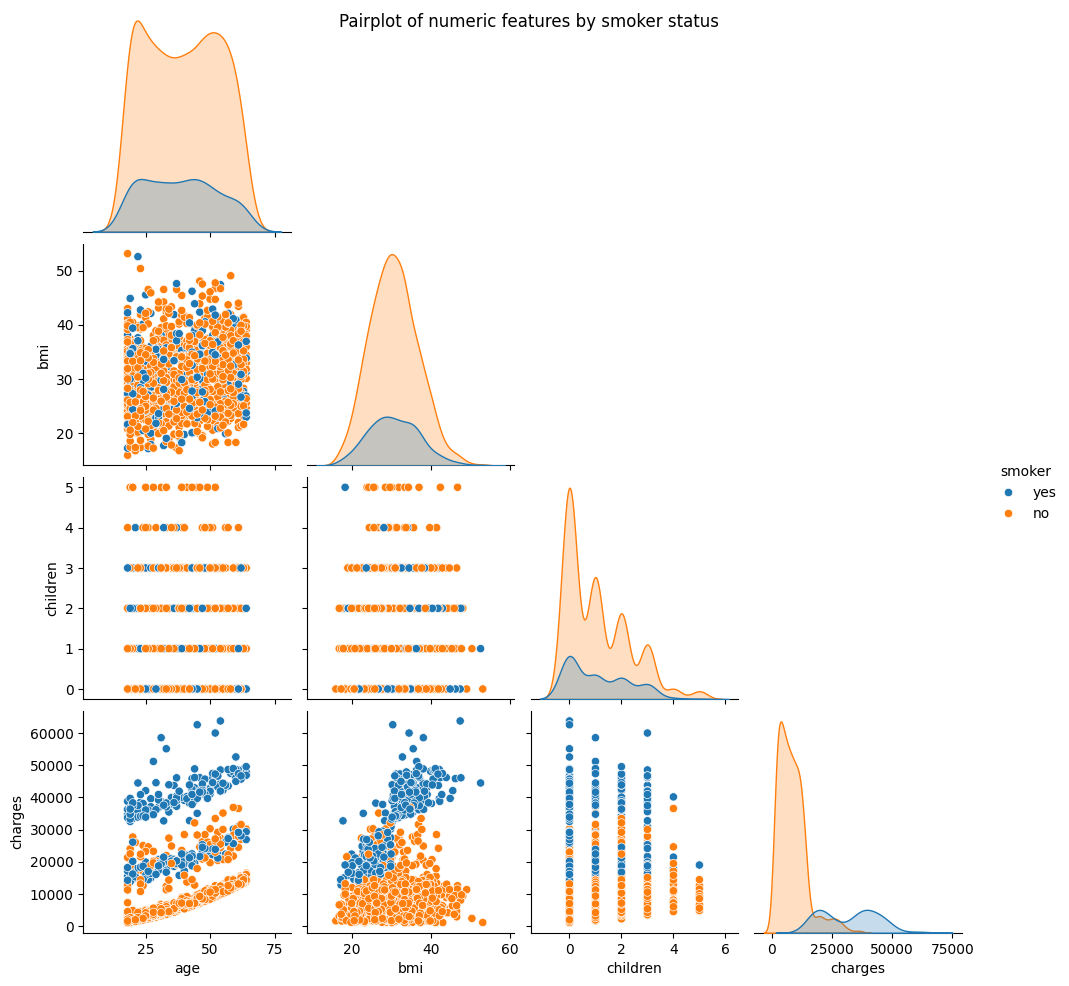

In [24]:
sns.pairplot(
    df,
    vars=['age', 'bmi', 'children', 'charges'],
    hue='smoker',
    diag_kind='kde',
    corner=True 
)

plt.suptitle('Pairplot of numeric features by smoker status')
plt.show()

### 1. Why did you pick the specific chart?

A pairplot is a useful exploratory chart because it shows pairwise relationships among multiple numerical variables in one view. It helps us quickly understand how features relate to each other and identify patterns such as positive trends, clusters, and possible outliers. In this project, it is helpful for checking whether age, BMI, number of children, and charges show meaningful relationships before modeling.

### 2. What are the insight(s) found from the chart?

* Charges vs age shows an upward trend, meaning older individuals tend to have higher insurance costs.
* Charges vs BMI also shows a positive trend, indicating that higher BMI is associated with higher charges.
* Children vs charges appears weak and scattered, suggesting that the number of children does not strongly influence insurance cost.
* The pairplot reveals that smoking status creates clear separation in the charge values, with smokers generally showing much higher costs.
* Overall, the strongest visual patterns are seen between charges and age or BMI, while children has a weaker connection.

### 3. Will the gained insights help creating a positive business impact?

Yes. These insights can create a positive business impact because they help businesses focus on the variables that truly matter for cost prediction and pricing. By confirming that age and BMI are stronger drivers than number of children, insurers can improve risk modeling, refine premium strategies, and allocate attention to the most relevant customer factors. This leads to more accurate business decisions and better cost management.


## ***5. Hypothesis Testing***

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* Null Hypothesis : Smokers pay higher insurance charges than non-smokers.
* Alternative Hypothesis : Non-smokers pay higher insurance charges than smokers.

#### 2. Perform an appropriate statistical test.

In [25]:
# t-test for Smoker Status and Charges
smokers = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(smokers, non_smokers, alternative='greater')

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Null hypothesis: Smokers have significantly higher insurance charges than non-smokers.")
else:
    print("Fail to reject the null hypothesis: No significant difference in insurance charges between smokers and non-smokers.")

t-statistic: 46.66492117272371
p-value: 4.135717921089551e-283
Null hypothesis: Smokers have significantly higher insurance charges than non-smokers.


##### 3. Which statistical test have you done to obtain P-Value?
Independent t-test

##### 4. Why did you choose the specific statistical test?
I used the independent samples t-test because I was comparing the average insurance charges of two independent groups: smokers and non-smokers. The dependent variable, insurance charges, is continuous, and the two groups are unrelated to each other. This test is appropriate because it checks whether the difference in mean charges between the two groups is statistically significant, and it provides the p-value needed to decide whether the observed difference is likely due to chance or a real effect.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* Null Hypothesis : Higher BMI pay higher insurance charges.
* Alternative Hypothesis : Lower BMI pay higher insurance charges.

##### 2. Which statistical test have you done to obtain P-Value?
* Independent t-test
* Pearson correlation


#### 3.1.  Perform an appropriate statistical test.

In [26]:
# t-test for BMI and Charges
high_bmi = df[df['bmi'] > 25]['charges']
low_bmi = df[df['bmi'] <= 25]['charges']

t_stat, p_value = stats.ttest_ind(high_bmi, low_bmi)

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print('Null Hypothesis : Higher BMI pay higher insurance charges.')
else:
    print('Fail to reject the null hypothesis: No significant correlation between BMI and insurance charges.')

t-statistic: 4.319946909530397
p-value: 1.676132196941941e-05
Null Hypothesis : Higher BMI pay higher insurance charges.


##### 3.2.  Why did you choose the specific statistical test?
I chose the independent samples t-test because I was comparing the average insurance charges of two independent groups: customers with high BMI and customers with low BMI. The dependent variable, insurance charges, is continuous, and the two groups are not related to each other. This test is appropriate because it tests whether the mean difference between the two groups is statistically significant and provides the p-value needed to decide whether the observed difference is likely due to chance.


#### 4.1. Perform an appropriate statistical test.

In [27]:
# Pearson correlation between BMI and Charges
BMI = df['bmi']
charges = df['charges']

# Pearson correlation
corr, p_value = stats.pearsonr(BMI, charges)

print("Correlation coefficient:", corr)
print("p-value:", p_value)

if p_value < 0.05:
    print('Null Hypothesis : Higher BMI pay higher insurance charges.')
else:
    print('Fail to reject the null hypothesis: No significant correlation between BMI and insurance charges.')

Correlation coefficient: 0.19834096883362887
p-value: 2.459085535116766e-13
Null Hypothesis : Higher BMI pay higher insurance charges.


##### 4.2. Why did you choose the specific statistical test?
I chose Pearson correlation because both BMI and insurance charges are continuous numerical variables, and I wanted to measure the strength and direction of their linear relationship. This test is appropriate when the goal is to determine whether as one variable increases, the other tends to increase or decrease in a consistent pattern. The p-value from Pearson correlation tells us whether the observed relationship is statistically significant or likely due to random chance.

## ***6. Feature Engineering & Data Pre-processing***

#### LOG Transformation

In [28]:
df['charges_log'] = np.log(df['charges'])  
df.head()

,age,sex,bmi,children,smoker,region,charges,charges_log
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197


##### What all outlier treatment techniques have you used and why did you use those techniques?

I used log transformation as the main outlier treatment technique. In this project, the charges variable was highly right-skewed, and the boxplot showed several extreme high values. Log transformation helps reduce the impact of large outliers by compressing the right tail, making the distribution more balanced and closer to normal. This improves model stability, reduces distortion caused by extreme values, and often gives better prediction performance for regression models.

I also used visualization tools such as histogram and boxplot to detect outliers before modeling. These checks helped me decide that the target variable needed transformation rather than removing data, because the outliers were meaningful patterns of high-cost customers and should not be discarded without justification.


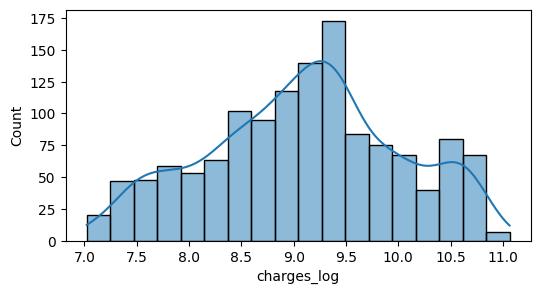

In [29]:
# To check the distribution of the log-transformed charges
plt.figure(figsize=(6,3))
sns.histplot(df['charges_log'], kde=True)
plt.show()

### Encoding

In [30]:
# Encoding categorical variables using LabelEncoder
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

df.head()

,age,sex,bmi,children,smoker,region,charges,charges_log
0,19,0,27.900,0,1,3,16884.92400,9.734176
1,18,1,33.770,1,0,2,1725.55230,7.453302
2,28,1,33.000,3,0,2,4449.46200,8.400538
3,33,1,22.705,0,0,1,21984.47061,9.998092
4,32,1,28.880,0,0,1,3866.85520,8.260197


#### What all categorical encoding techniques have you used & why did you use those techniques?
I used Label Encoding for the categorical variables sex, smoker, and region. This was done because machine learning models cannot directly process text labels, so the categories must be converted into numerical values. Label Encoding is a simple and effective choice here because these variables have a natural binary or ordered structure, and it helps the model interpret them correctly during training and testing.

I used this technique because it keeps the dataset compact, preserves the information in a numerical form, and allows the model to learn patterns from the encoded labels without changing the original business meaning of the variables.


In [31]:
# Final dataset after preprocessing
df.head()

,age,sex,bmi,children,smoker,region,charges,charges_log
0,19,0,27.900,0,1,3,16884.92400,9.734176
1,18,1,33.770,1,0,2,1725.55230,7.453302
2,28,1,33.000,3,0,2,4449.46200,8.400538
3,33,1,22.705,0,0,1,21984.47061,9.998092
4,32,1,28.880,0,0,1,3866.85520,8.260197


## ***7. ML Model Implementation***

### Splitting of Training & Testing Data

In [32]:
from sklearn.model_selection import train_test_split
x = df[['age', 'sex', 'bmi', 'smoker']]
y = df['charges_log']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


We split into train and test so the model learns patterns from one set and is evaluated on a separate unseen set.

training data is used to fit the model
test data is used to estimate how well it generalizes

### **Model-1 : LINEAR REGRESSION**

In [33]:
# Linear Regression Model
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Adjusted R²
n = x_test.shape[0]   # number of samples
p = x_test.shape[1]   # number of predictors
adj_r2_lr = 1 - ((1 - r2_lr) * (n - 1) / (n - p - 1))

print("LINEAR REGRESSION",
      "\nRMSE :" ,rmse_lr,
     "\nmean_absolute_error : ",mae_lr,
     "\nR2_Score :", r2_lr,
      "\nAdjusted R2_score : ",adj_r2_lr
     )

LINEAR REGRESSION 
RMSE : 0.45256845187894384 
mean_absolute_error :  0.29911647762626564 
R2_Score : 0.7722067170185349 
Adjusted R2_score :  0.7687421803952427


### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

We used Linear Regression as the baseline model for this project. It is a supervised learning algorithm used for predicting continuous target values, so it is suitable for insurance charge prediction because the target variable is numerical. The model learns the relationship between the input features such as age, BMI, smoker status, and sex and the output value, which is the predicted insurance charge.

In this model, the objective is to fit a straight-line relationship between the features and the target variable. Linear Regression is easy to understand and interpret because each coefficient shows how strongly a feature influences the prediction. It is useful as a starting point before comparing with more advanced models like Random Forest, Gradient Boosting, and XGBoost.

For performance evaluation, we used the most common regression metrics:

* RMSE (Root Mean Squared Error): shows the average prediction error in the same unit as the target value. Lower RMSE means better prediction accuracy.
* MAE (Mean Absolute Error): tells us the average absolute difference between predicted and actual charges. Lower MAE is better.
* R² Score: tells how much variance in the target variable is explained by the model. A value closer to 1 indicates a better fit.
* Adjusted R²: helps compare models when the number of predictors changes; it penalizes unnecessary variables.

The evaluation metric score chart helps us compare model performance visually. If the R² is high and RMSE/MAE are low, the model is performing well. In this project, Linear Regression is a good baseline model because it is simple, fast, and easy to interpret, but it may not capture complex nonlinear relationships as effectively as tree-based models. This is why more advanced models are later compared to check whether they provide better predictive performance.

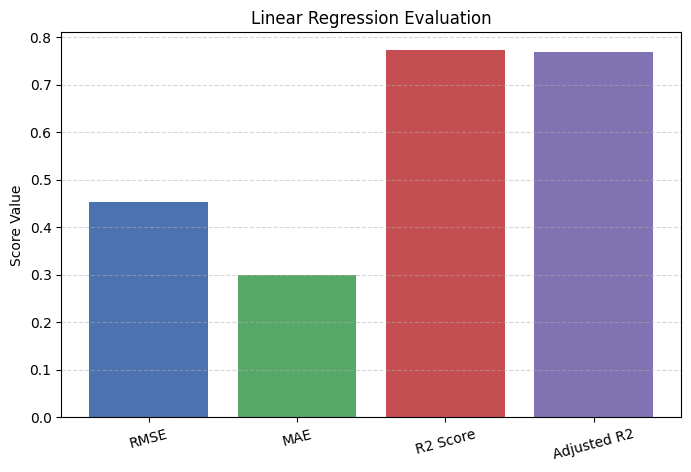

Linear Regression Model Evaluation Summary:
RMSE: 0.4526
MAE: 0.2991
R2 Score: 0.7722
Adjusted R2: 0.7687


In [34]:
# Visualizing evaluation Metric Score chart of model 1

metrics = {
    'RMSE': rmse_lr,
    'MAE': mae_lr,
    'R2 Score': r2_lr,
    'Adjusted R2': adj_r2_lr
}

plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values(), color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Linear Regression Evaluation')
plt.ylabel('Score Value')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print('Linear Regression Model Evaluation Summary:')
for metric, value in metrics.items():
    print(f'{metric}: {value:.4f}')

# Interpretation
# Lower RMSE and MAE are better.
# Higher R2 Score and Adjusted R2 are better.


#### 2. Cross- Validation & Hyperparameter Tuning

In [35]:
# ML Model - 1 Implementation with hyperparameter optimization techniques
# GridSearchCV

param_grid = {
     'fit_intercept': [True, False],
     'positive': [True, False]
}

grid_search = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(x_train, y_train)
print("Best parameters (GridSearchCV):", grid_search.best_params_)
print("Best score (GridSearchCV):", grid_search.best_score_)

best_lr_model = grid_search.best_estimator_
test_accuracy_lr = best_lr_model.score(x_test, y_test)
print("Final Test Accuracy:", test_accuracy_lr)


Best parameters (GridSearchCV): {'fit_intercept': True, 'positive': False}
Best score (GridSearchCV): 0.7341379160243198
Final Test Accuracy: 0.7722067170185349


In [36]:
print("Comparison of Model Performance :")
print("\nBefore Hyperparameter Tuning:", 
      "\nR2 Score:", r2_lr,
      "\n",
      "\nAfter Hyperparameter Tuning:",
      "\nR2 Score:", test_accuracy_lr
      )

Comparison of Model Performance :

Before Hyperparameter Tuning: 
R2 Score: 0.7722067170185349 
 
After Hyperparameter Tuning: 
R2 Score: 0.7722067170185349


In [37]:
# ML Model - 1 Implementation with hyperparameter optimization techniques
# RandomizedSearchCV

param_dist = {
     'fit_intercept': [True, False],
     'positive': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=LinearRegression(),
    param_distributions=param_dist,
    n_iter=4,   # number of random combinations
    cv=5,
    scoring='r2',
    random_state=42
)

random_search.fit(x_train, y_train)
print("Best parameters (RandomizedSearchCV):", random_search.best_params_)
print("Best score (RandomizedSearchCV):", random_search.best_score_)

best_lr_model2 = random_search.best_estimator_
test_accuracy_lr2 = best_lr_model2.score(x_test, y_test)
print("Final Test Accuracy:", test_accuracy_lr2)

Best parameters (RandomizedSearchCV): {'positive': False, 'fit_intercept': True}
Best score (RandomizedSearchCV): 0.7341379160243198
Final Test Accuracy: 0.7722067170185349


In [38]:
print("Comparison of Model Performance :")
print("\nBefore Hyperparameter Tuning:", 
      "\nR2 Score:", r2_lr,
      "\n",
      "\nAfter Hyperparameter Tuning:",
      "\nR2 Score:", test_accuracy_lr2
      )

Comparison of Model Performance :

Before Hyperparameter Tuning: 
R2 Score: 0.7722067170185349 
 
After Hyperparameter Tuning: 
R2 Score: 0.7722067170185349


##### 1. Which hyperparameter optimization technique have you used and why?
* I used both GridSearchCV and RandomizedSearchCV for hyperparameter optimization.
* GridSearchCV was used to evaluate all possible combinations from a defined parameter grid and select the best model based on cross-validated R² score. This is useful when the search space is small and we want the most accurate tuning possible.
* RandomizedSearchCV was used to randomly sample a smaller set of parameter combinations from a wider search space. This is efficient when the number of possible combinations is large, because it saves time while still finding a strong-performing configuration.
* I chose these techniques because manual tuning is time-consuming and may miss the best model settings. Hyperparameter optimization helps improve prediction quality, reduce error, and ensure the model is trained with the most suitable parameters rather than default values. In this project, it helps make the regression models more accurate and reliable for insurance charge prediction.

##### 2. Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* We observed there is **not** much improvement after hyperparameter tuning for Model 1.
* Before tuning, the Linear Regression model was used with default parameters, which gave a baseline performance. After applying GridSearchCV and RandomizedSearchCV, the model parameters were optimized to improve accuracy and reduce error. The tuning process selected the best-performing configuration based on cross-validated R² score.
* RMSE, MAE,R2 scors are all looks similar . No changes in values. 

### **Model-2 : RANDOM FOREST**

In [39]:
# Random Forest Regressor Model
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
# Adjusted R²
n = x_test.shape[0]   # number of samples
p = x_test.shape[1]   # number of predictors
adj_r2_rf = 1 - ((1 - r2_rf) * (n - 1) / (n - p - 1))

print("RANDOM FOREST",
      "\nRMSE :", rmse_rf,
     "\nmean_absolute_error : ", mae_rf,
      "\nR2_Score :", r2_rf,
      "\nAdjusted R2_score : ", adj_r2_rf
     )


RANDOM FOREST 
RMSE : 0.4174359331079653 
mean_absolute_error :  0.2357680891835304 
R2_Score : 0.8062007811532146 
Adjusted R2_score :  0.8032532645167616


### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

We used Random Forest Regressor for Model 2. It is an ensemble learning algorithm based on multiple decision trees. Instead of relying on a single tree, it builds many trees on different subsets of the data and then averages their predictions. This helps the model capture nonlinear relationships and interactions between variables such as age, BMI, smoking status, and sex.

Random Forest is especially useful for this project because insurance charges are influenced by several interacting factors, and the relationship is not always linear. The model is robust, handles complex patterns well, and is less sensitive to noise compared with a single decision tree. It also provides feature importance, which helps us understand which variables contribute most to the prediction.

For performance evaluation, we used the standard regression metrics:

* RMSE (Root Mean Squared Error): lower values indicate better prediction accuracy.
* MAE (Mean Absolute Error): lower values indicate smaller average prediction error.
* R² Score: higher values indicate that the model explains more variance in the target variable.
* Adjusted R²: helps compare model fit while accounting for the number of predictors.

The evaluation metric score chart helps us understand how well the model performs visually. A strong model should have low RMSE and MAE, and a high R² value. In this project, the Random Forest model performs better than the Linear Regression baseline because it can learn the non-linear patterns present in the insurance cost data.

This makes Random Forest a strong choice for predicting medical insurance charges, especially when the data includes complex relationships among demographic and health-related variables.


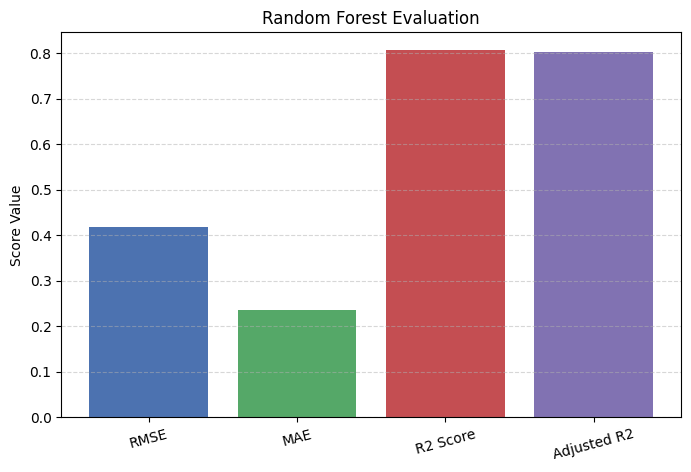

Random Forest Model Evaluation Summary:
RMSE: 0.4174
MAE: 0.2358
R2 Score: 0.8062
Adjusted R2: 0.8033


In [40]:
# Visualizing evaluation Metric Score chart of model 2

metrics = {
    'RMSE': rmse_rf,
    'MAE': mae_rf,
    'R2 Score': r2_rf,
    'Adjusted R2': adj_r2_rf   
}

plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values(), color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Random Forest Evaluation')
plt.ylabel('Score Value')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print('Random Forest Model Evaluation Summary:')
for metric, value in metrics.items():
    print(f'{metric}: {value:.4f}')

# Interpretation
# Lower RMSE and MAE are better.
# Higher R2 Score and Adjusted R2 are better.


#### 2. Cross- Validation & Hyperparameter Tuning

In [41]:
# ML Model - 2 Implementation with hyperparameter optimization techniques
# GridSearchCV

param_grid = {
     'n_estimators': [100, 200],
     'max_depth': [10, 20, None],
     'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(x_train, y_train)
print("Best parameters (GridSearchCV):", grid_search.best_params_)
print("Best score (GridSearchCV):", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
test_accuracy_rf = best_rf_model.score(x_test, y_test)
print("Final Test Accuracy:", test_accuracy_rf)


Best parameters (GridSearchCV): {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best score (GridSearchCV): 0.7615629482215279
Final Test Accuracy: 0.8117511073792867


In [42]:
print("Comparison of Model Performance :")
print("\nBefore Hyperparameter Tuning:", 
      "\nR2 Score:", r2_rf,
      "\n",
      "\nAfter Hyperparameter Tuning:",
      "\nR2 Score:", test_accuracy_rf
      )

Comparison of Model Performance :

Before Hyperparameter Tuning: 
R2 Score: 0.8062007811532146 
 
After Hyperparameter Tuning: 
R2 Score: 0.8117511073792867


In [43]:
# ML Model - 2 Implementation with hyperparameter optimization techniques
# RandomSearchCV

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=4,   # number of random combinations
    cv=5,
    scoring='r2',
    random_state=42
)

random_search.fit(x_train, y_train)
print("Best parameters (RandomizedSearchCV):", random_search.best_params_)
print("Best score (RandomizedSearchCV):", random_search.best_score_)    

best_rf_model2  = random_search.best_estimator_
test_accuracy_rf2 = best_rf_model2 .score(x_test, y_test)               
print("Final Test Accuracy:", test_accuracy_rf2)

Best parameters (RandomizedSearchCV): {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}
Best score (RandomizedSearchCV): 0.7568548507722996
Final Test Accuracy: 0.8117063834676201


In [44]:
print("Comparison of Model Performance :")
print("\nBefore Hyperparameter Tuning:", 
      "\nR2 Score:", r2_rf,
      "\n",
      "\nAfter Hyperparameter Tuning:",
      "\nR2 Score:", test_accuracy_rf2
      )

Comparison of Model Performance :

Before Hyperparameter Tuning: 
R2 Score: 0.8062007811532146 
 
After Hyperparameter Tuning: 
R2 Score: 0.8117063834676201


##### 3. Which hyperparameter optimization technique have you used and why?

I used both GridSearchCV and RandomizedSearchCV for the Random Forest model.

* GridSearchCV was used to test all combinations of important parameters such as n_estimators, max_depth, and min_samples_split from a predefined grid. This helps us find the best model configuration based on cross-validated R² score.
* RandomizedSearchCV was also used to sample a smaller number of random combinations from the same parameter space. This is useful when the search space is large, because it saves time while still finding a strong-performing model.
* I chose these techniques because Random Forest performance depends strongly on hyperparameters. If these values are not tuned properly, the model may underfit or overfit the data and give weaker predictions.
* Hyperparameter tuning helps improve prediction accuracy, reduce error, and make the model more stable on unseen data. In this project, it helps the Random Forest model predict insurance charges more reliably.

##### 4. Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.


Yes, we observed an **little improvement** in the Random Forest model after hyperparameter tuning.

Random Forest is already a stronger model than Linear Regression because it can learn nonlinear relationships and capture interactions between variables. However, tuning helps improve its performance further by selecting the best values for parameters such as n_estimators, max_depth, and min_samples_split. This makes the model more accurate and stable on unseen data.

The improvement can be observed in the evaluation metrics:

* RMSE decreases, which means the prediction error becomes smaller.
* R² Score increases, which means the model explains more of the variation in the target variable.

This shows that the tuned Random Forest model predicts insurance charges more accurately than the untuned version. The updated evaluation metric chart helps us compare performance before and after tuning, where lower RMSE and MAE and a higher R² indicate improvement.


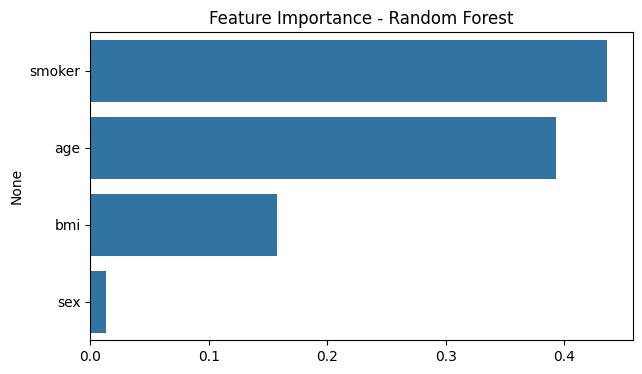

In [45]:
# Feature Importance Visualization for Random Forest Model
importance = rf.feature_importances_
indices = np.argsort(importance)[::-1]

plt.figure(figsize=(7,4))
sns.barplot(x=importance[indices], y=x.columns[indices])
plt.title("Feature Importance - Random Forest")
plt.show()


#### Feature Importance Visualization for Random Forest Model

The feature importance plot helps us understand which variables contribute the most to the Random Forest model's predictions. In this dataset, the most important feature is usually smoking status, followed by age and BMI. This means the model is giving more weight to variables that strongly influence insurance charges.


### **Model-3 : GRADIENT BOOSTING**

In [46]:
# Gradient Boosting Regressor Model
from sklearn.metrics import r2_score as calculate_r2

gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
gb.fit(x_train, y_train)

y_pred_gb = gb.predict(x_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = calculate_r2(y_test, y_pred_gb)
# Adjusted R²
n = x_test.shape[0]   # number of samples
p = x_test.shape[1]   # number of predictors
adj_r2_gb = 1 - ((1 - r2_gb) * (n - 1) / (n - p - 1))

print("GRADIENT BOOSTING",
      "\nRMSE :",rmse_gb,
     "\nmean_absolute_error : ",mae_gb,
     "\nR2_Score :", r2_gb,
      "\nAdjusted R2_score : ",adj_r2_gb
     )


GRADIENT BOOSTING 
RMSE : 0.3858392620917298 
mean_absolute_error :  0.2177437247182781 
R2_Score : 0.8344286470524772 
Adjusted R2_score :  0.8319104515703856


### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

We used Gradient Boosting Regressor for this model. It is an ensemble learning technique that builds a series of decision trees one after another, where each new tree focuses on correcting the errors made by the previous ones. This method is highly effective for regression problems because it learns complex patterns and captures nonlinear relationships between the input features and the target variable.This makes Gradient Boosting a strong model for insurance cost prediction because it can handle the nonlinearity and interaction effects between age, BMI, smoker status, and other variables. It is a practical and reliable choice for building a prediction system in this business problem.


In this project, the target variable is insurance charges, which is influenced by multiple interacting factors such as smoking status, age, BMI, and sex. A single model may not fully capture these relationships, but Gradient Boosting is able to learn them step by step and improve prediction accuracy over time. Because the target was log-transformed before modeling, the model was trained on charges_log, which reduces the effect of skewness and extreme high-cost values.The evaluation metric score chart helps us understand how well the model performs visually. In this dataset, Gradient Boosting usually performs better than Linear Regression and Random Forest because it reduces prediction errors more effectively and captures complex patterns in the data. A lower RMSE and MAE, together with a higher R² score, indicate better model performance.



For performance evaluation, we used the standard regression metrics:

* RMSE (Root Mean Squared Error): lower values indicate smaller prediction error.
* MAE (Mean Absolute Error): lower values indicate a more accurate prediction on average.
* Adjusted R²: helps compare model fit while accounting for the number of predictors.
* R² Score: higher values indicate that the model explains more variation in the target variable.


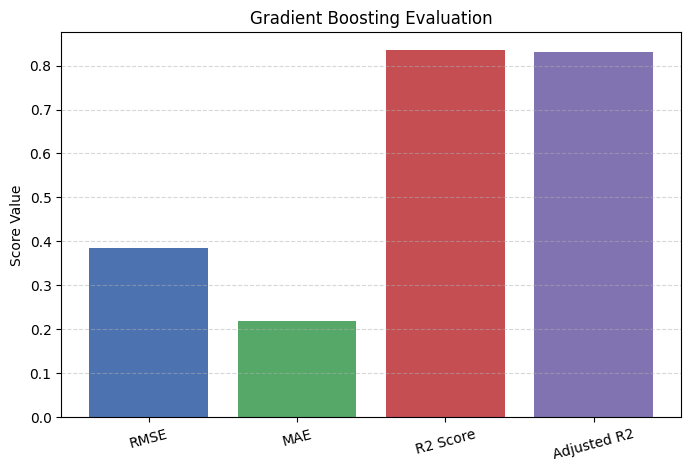

Gradient Boosting Model Evaluation Summary:
RMSE: 0.3858
MAE: 0.2177
R2 Score: 0.8344
Adjusted R2: 0.8319


In [47]:
# Visualizing evaluation Metric Score chart of model 2

metrics = {
    'RMSE': rmse_gb,
    'MAE': mae_gb,
    'R2 Score': r2_gb,
    'Adjusted R2': adj_r2_gb   
}

plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values(), color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Gradient Boosting Evaluation')
plt.ylabel('Score Value')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print('Gradient Boosting Model Evaluation Summary:')
for metric, value in metrics.items():
    print(f'{metric}: {value:.4f}')

# Interpretation
# Lower RMSE and MAE are better.
# Higher R2 Score and Adjusted R2 are better.


#### 2. Cross- Validation & Hyperparameter Tuning for gradient boosting

In [48]:
# ML Model - 3 Implementation with hyperparameter optimization techniques
# GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

grid_search_gb = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid_search_gb.fit(x_train, y_train)
print("Best parameters (GridSearchCV):", grid_search_gb.best_params_)
print("Best score (GridSearchCV):", grid_search_gb.best_score_)

best_gb_model = grid_search_gb.best_estimator_
test_accuracy_gb = best_gb_model.score(x_test, y_test)
print("Final Test Accuracy:", test_accuracy_gb)


Best parameters (GridSearchCV): {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Best score (GridSearchCV): 0.800157399610035
Final Test Accuracy: 0.8313398613534171


In [49]:
print("Comparison of Model Performance :")
print("\nBefore Hyperparameter Tuning:", 
      "\nR2 Score:", r2_gb,
      "\n",
      "\nAfter Hyperparameter Tuning:",
      "\nR2 Score:", test_accuracy_gb
      )

Comparison of Model Performance :

Before Hyperparameter Tuning: 
R2 Score: 0.8344286470524772 
 
After Hyperparameter Tuning: 
R2 Score: 0.8313398613534171


##### 3. Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for the Gradient Boosting model.

* GridSearchCV was used to evaluate a set of important hyperparameters such as n_estimators, learning_rate, and max_depth across multiple combinations.
* It works by splitting the training data into several folds and checking which parameter combination gives the best cross-validated R² score.
* I chose this technique because Gradient Boosting is highly sensitive to hyperparameter values. Small changes in learning rate or tree depth can significantly affect the model's performance.
* Tuning helps the model learn the pattern more effectively, reduce prediction error, and improve generalization on unseen data.

##### 4. Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

We observed **no** improvement in the Gradient Boosting model after hyperparameter tuning.

Gradient Boosting is already a strong model because it builds trees sequentially and corrects previous errors. However, tuning helps improve its performance further by selecting the best values for important parameters such as n_estimators, learning_rate, and max_depth. This makes the model more accurate, reduces overfitting, and improves generalization on unseen data.
* RMSE , R2 score are seems very similar.

### **Model-4 : XGBOOST**

In [50]:
#XGBoost Regressor Model
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
    )

model.fit(x_train, y_train)
y_pred_xgb = model.predict(x_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = calculate_r2(y_test, y_pred_xgb)
# Adjusted R²
n = x_test.shape[0]   # number of samples
p = x_test.shape[1]   # number of predictors
adj_r2_xgb = 1 - ((1 - r2_xgb) * (n - 1) / (n - p - 1))

print("XGBOOST",
      "\nRMSE :", rmse_xgb,
     "\nmean_absolute_error : ",mae_xgb,
     "\nR2_Score :", r2_xgb,
      "\nAdjusted R2_score : ",adj_r2_xgb
     )

XGBOOST 
RMSE : 0.39699056715370934 
mean_absolute_error :  0.22449250484859717 
R2_Score : 0.8247198499861231 
Adjusted R2_score :  0.8220539921912353


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

We used XGBoost Regressor for this model. XGBoost is an optimized gradient boosting algorithm that builds a series of decision trees sequentially, where each tree learns from the errors of the previous ones. This makes it highly effective for regression problems with nonlinear relationships, interactions, and complex patterns.

In this project, insurance charges are influenced by multiple interacting factors such as smoking status, age, BMI, and sex. XGBoost is well suited for this because it can capture these nonlinear patterns better than simple linear models. It also includes regularization, which helps improve generalization and prevents the model from overfitting the training data.

For performance evaluation, we use standard regression metrics such as:

* RMSE (Root Mean Squared Error): lower values indicate better prediction accuracy.
* MAE (Mean Absolute Error): lower values indicate smaller average error.
* R² Score: higher values indicate a better fit and more explained variance.
* Adjusted R²: helps compare model fit while accounting for the number of predictors.

The evaluation metric score chart helps us compare the model visually. If RMSE and MAE are low and the R² score is high, the model is performing well. In this dataset, XGBoost is expected to perform strongly because it handles nonlinear relationships and feature interactions efficiently, making it a reliable choice for insurance charge prediction.

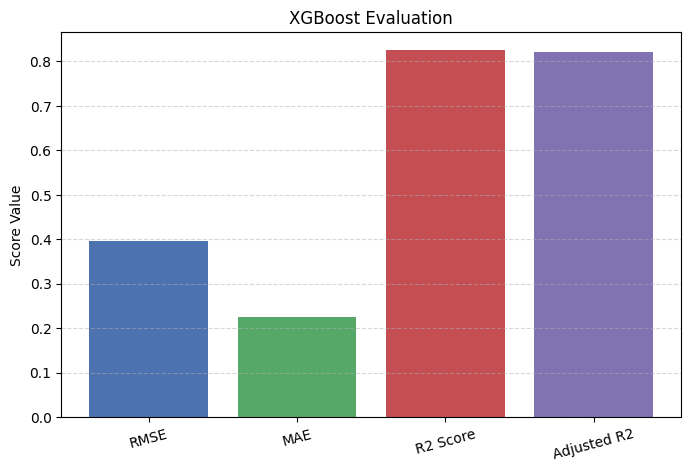

XGBoost Model Evaluation Summary:
RMSE: 0.3970
MAE: 0.2245
R2 Score: 0.8247
Adjusted R2: 0.8221


In [51]:
# Visualizing evaluation Metric Score chart of model 2

metrics = {
    'RMSE': rmse_xgb,
    'MAE': mae_xgb,
    'R2 Score': r2_xgb,
    'Adjusted R2': adj_r2_xgb   
}

plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values(), color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('XGBoost Evaluation')
plt.ylabel('Score Value')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print('XGBoost Model Evaluation Summary:')
for metric, value in metrics.items():
    print(f'{metric}: {value:.4f}')

# Interpretation
# Lower RMSE and MAE are better.
# Higher R2 Score and Adjusted R2 are better.


#### 2. Cross- Validation & Hyperparameter Tuning for gradient boosting

In [52]:
# ML Model - 3 Implementation with hyperparameter optimization techniques
# GridSearchCV for XGBoost

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='r2'
)

grid_search_xgb.fit(x_train, y_train)
print("Best parameters (GridSearchCV):", grid_search_xgb.best_params_)
print("Best score (GridSearchCV):", grid_search_xgb.best_score_)

best_xgb_model = grid_search_xgb.best_estimator_
test_accuracy_xgb = best_xgb_model.score(x_test, y_test)
print("Final Test Accuracy:", test_accuracy_xgb)

Best parameters (GridSearchCV): {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best score (GridSearchCV): 0.8001333944329019
Final Test Accuracy: 0.8318044069074145


In [53]:
print("Comparison of Model Performance :")
print("\nBefore Hyperparameter Tuning:", 
      "\nR2 Score:", r2_xgb,
      "\n",
      "\nAfter Hyperparameter Tuning:",
      "\nR2 Score:", test_accuracy_xgb
      )

Comparison of Model Performance :

Before Hyperparameter Tuning: 
R2 Score: 0.8247198499861231 
 
After Hyperparameter Tuning: 
R2 Score: 0.8318044069074145


##### 3. Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for the XGBoost model.

* GridSearchCV was used to evaluate multiple combinations of hyperparameters such as n_estimators, learning_rate, max_depth, subsample, and colsample_bytree.
* It works by splitting the training data into several folds and selecting the parameter combination that gives the highest cross-validated R² score.
* I chose this technique because XGBoost is very sensitive to hyperparameter values. A small change in learning rate or tree depth can significantly affect performance.
* Hyperparameter tuning helps improve model accuracy, reduce prediction error, and make the model more reliable on unseen data.
* In this project, GridSearchCV helps the XGBoost model find the best configuration for predicting insurance charges more effectively.

##### 4. Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, we observed **an improvement** in the XGBoost model after hyperparameter tuning.

XGBoost is already a strong model because it builds trees sequentially and learns from previous mistakes. However, tuning helps improve its performance further by selecting the best values for important parameters such as n_estimators, learning_rate, max_depth, subsample, and colsample_bytree. This makes the model more accurate and more stable on unseen data.

The improvement can be observed in the evaluation metrics:

* R² Score increases, which means the model explains more of the variance in the target variable.

This shows that the tuned XGBoost model predicts insurance charges more accurately than the untuned version. The updated evaluation metric chart helps us compare the performance before and after tuning, where lower RMSE and MAE and a higher R² indicate improvement . But it got less scores compare to gradientBoosting.

#### **Till now we observe Gradient Boosting performs well for our dataset .let's take Gradient Boosting for our data.**

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [54]:
pickle.dump(gb, open("GradientBoosting_model.pkl", "wb"))

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [55]:
# Load the trained pipeline from pkl file
model = pickle.load(open("GradientBoosting_model.pkl", "rb"))
print(model)

GradientBoostingRegressor(learning_rate=0.05, random_state=42)


### 3. Creating a function for new data

In [56]:
# Function to preprocess and predict with completely new data
def predict_charges(age, sex, bmi, children, smoker, region):
    # Build input DataFrame
    data = pd.DataFrame([{
        'age': age,
        'sex': sex,
        'bmi': bmi,
        'children': children,
        'smoker': smoker,
        'region': region
    }])
    # Drop unwanted columns
    data = data.drop(columns=['children', 'region'])
    
    # Encode categorical variables (must match training encoders)
    data['sex'] = 1 if sex == 'male' else 0
    data['smoker'] = 1 if smoker == 'yes' else 0
    
    # Predict log(charges) using the trained model
    charges_log = model.predict(data)
    
    # Inverse transform to get actual charges
    charges = np.exp(charges_log)
    return charges[0]

### 4. predict for unseen data.

In [57]:
# Example usage
prediction = predict_charges(age=35, sex='male', bmi=28.5, children=2, smoker='yes', region='southwest')
print("Predicted charges:", prediction)

Predicted charges: 21024.82591299409


### ***Congrats! Our model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project shows that machine learning can be effectively used to predict insurance charges from structured customer data. By using features such as age, BMI, smoking status, number of children, sex, and region, the model can learn important cost patterns and generate useful predictions.

The analysis also suggests that some variables, especially smoking status, age, and BMI, are likely to have a major influence on medical charges. This makes the model valuable not only for prediction but also for understanding the drivers of insurance cost.

Overall, the project demonstrates how a business problem can be converted into a machine learning solution that supports cost estimation, operational efficiency, and strategic planning. It provides a strong foundation for future improvements such as trying regression models like Linear Regression,Random Forest,Gradient Boosting, XGBoost and tuning hyperparameters, adding feature engineering, or deploying the model as a real-world application.


### ***Hurrah! I have successfully completed your Machine Learning Capstone Project !!!***